In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!pip install tensorflow

In [ ]:
# Install necessary libraries
!pip install tensorflow scikit-learn imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, Input, BatchNormalization, Flatten, Concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/mexico_earthquake_final_data.csv') # loading train Dataset

In [ ]:
train .head(5)

,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,9.105230e+17,910523364154003456_0,not_informative,1.0000,not_informative,1.0000,not_humanitarian,1.0000,not_humanitarian,1.0000,NaN,NaN,RT @FCBarcelona: Our solidarity with the victi...,http://pbs.twimg.com/media/DKLLdbyW0AASG2R.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
1,9.105230e+17,910523388598280192_0,informative,1.0000,informative,0.6720,injured_or_dead_people,1.0000,infrastructure_and_utility_damage,0.6720,dont_know_or_cant_judge,0.4174,Mexico earthquake: Many children killed at pri...,http://pbs.twimg.com/media/DKLUMbJV4AACuFU.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
2,9.105230e+17,910523397448314882_0,not_informative,0.6643,not_informative,1.0000,not_humanitarian,0.6643,not_humanitarian,1.0000,NaN,NaN,Obamaâ€™s Response To The Earthquake In #Mexic...,http://pbs.twimg.com/media/DKLUND8WAAAHgON.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
3,9.105230e+17,910523398144397312_0,informative,0.9282,informative,1.0000,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,1.0000,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1CuDWsAAX5Vk.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
4,9.105230e+17,910523398144397312_1,informative,0.9282,informative,0.6943,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,0.6943,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1DyDXkAABvBX.jpg,data_image/mexico_earthquake/20_9_2017/9105233...


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tweet_id           1380 non-null   float64
 1   image_id           1380 non-null   object 
 2   text_info          1380 non-null   object 
 3   text_info_conf     1380 non-null   float64
 4   image_info         1380 non-null   object 
 5   image_info_conf    1380 non-null   float64
 6   text_human         1380 non-null   object 
 7   text_human_conf    1380 non-null   float64
 8   image_human        1380 non-null   object 
 9   image_human_conf   1380 non-null   float64
 10  image_damage       182 non-null    object 
 11  image_damage_conf  182 non-null    float64
 12  tweet_text         1380 non-null   object 
 13  image_url          1380 non-null   object 
 14  image_path         1380 non-null   object 
dtypes: float64(6), object(9)
memory usage: 161.8+ KB


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

In [ ]:
import re
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def remove_links(text):
    return re.sub(r'http\S+', '', text)

def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

def remove_hashtags(text):
    return re.sub(r'#\w+', '', text)

def convert_to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

In [ ]:
def remove_english_stopwords(text):
    arabic_stopwords = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in arabic_stopwords]
    return ' '.join(filtered_words)

In [ ]:
train['tweet_text'] = train['tweet_text'].apply(remove_links)
train['tweet_text'] = train['tweet_text'].apply(remove_punctuation)
train['tweet_text'] = train['tweet_text'].apply(remove_emojis)
train['tweet_text'] = train['tweet_text'].apply(remove_english_stopwords)
train['tweet_text'] = train['tweet_text'].apply(convert_to_lowercase)
train['tweet_text'] = train['tweet_text'].apply(remove_mentions)
train['tweet_text'] = train['tweet_text'].apply(remove_hashtags)

In [ ]:
# Drop unnecessary columns
train.drop(['image_id', 'image_info', 'image_info_conf', 'image_human', 'image_human_conf',
            'image_damage', 'image_damage_conf', 'image_url', 'tweet_id',
            'text_info_conf', 'text_human_conf', 'text_human'], axis=1, inplace=True)

In [ ]:
train.tweet_text

,tweet_text
0,rt fcbarcelona our solidarity victims earthqua...
1,mexico earthquake many children killed primary...
2,obamaâ€™s response to the earthquake in mexico...
3,rt amichaistein1 breaking israel search amp re...
4,rt amichaistein1 breaking israel search amp re...
...,...
1375,carlos santana donates 100k mexico earthquake ...
1376,seth troxler donates 10k earthquake relief eff...
1377,entercomsan francisco stations raise funds for...
1378,mexico earthquakes international medical corps...


In [ ]:
train.head(5)

,text_info,tweet_text,image_path
0,not_informative,rt fcbarcelona our solidarity victims earthqua...,data_image/mexico_earthquake/20_9_2017/9105233...
1,informative,mexico earthquake many children killed primary...,data_image/mexico_earthquake/20_9_2017/9105233...
2,not_informative,obamaâ€™s response to the earthquake in mexico...,data_image/mexico_earthquake/20_9_2017/9105233...
3,informative,rt amichaistein1 breaking israel search amp re...,data_image/mexico_earthquake/20_9_2017/9105233...
4,informative,rt amichaistein1 breaking israel search amp re...,data_image/mexico_earthquake/20_9_2017/9105233...


In [ ]:
train['text_info'].unique()

array(['not_informative', 'informative'], dtype=object)

In [ ]:
# Encode the sentiment labels
label_encoder = LabelEncoder()
train['text_info'] = label_encoder.fit_transform(train['text_info'])

In [ ]:
train['text_info'].unique()

array([1, 0])

In [ ]:
train.head(5)

,text_info,tweet_text,image_path
0,1,rt fcbarcelona our solidarity victims earthqua...,data_image/mexico_earthquake/20_9_2017/9105233...
1,0,mexico earthquake many children killed primary...,data_image/mexico_earthquake/20_9_2017/9105233...
2,1,obamaâ€™s response to the earthquake in mexico...,data_image/mexico_earthquake/20_9_2017/9105233...
3,0,rt amichaistein1 breaking israel search amp re...,data_image/mexico_earthquake/20_9_2017/9105233...
4,0,rt amichaistein1 breaking israel search amp re...,data_image/mexico_earthquake/20_9_2017/9105233...


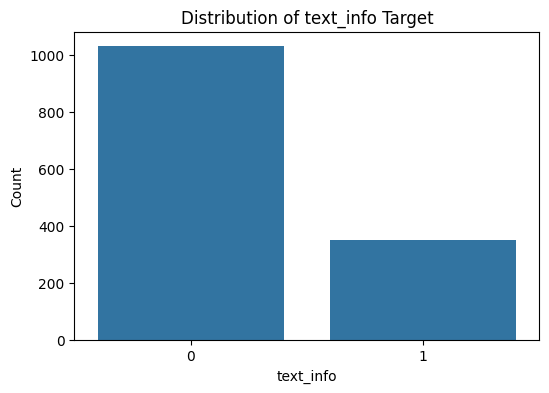

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of 'text_info' target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='text_info', data=train)
plt.title('Distribution of text_info Target')
plt.xlabel('text_info')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# If train['tweet_text'] is a list of lists
if isinstance(train['tweet_text'][0], list):
    train['tweet_text'] = [' '.join(map(str, sublist)) for sublist in train['tweet_text']]

# Apply TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))  # Adjust the max_features as needed
X_text = vectorizer.fit_transform(train['tweet_text']).toarray()

In [ ]:
# Apply SMOTE to oversample the minority classes
smote = SMOTE(random_state=42)
X_text_resampled, y_resampled = smote.fit_resample(X_text, train['text_info'])

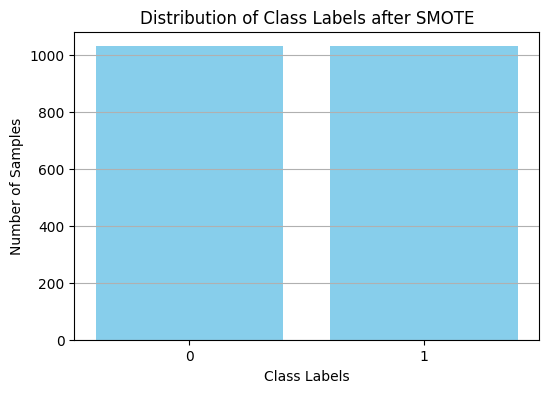

In [ ]:
# Count the occurrences of each class label
from collections import Counter

counter = Counter(y_resampled)

# Extract class labels and their corresponding counts
labels, values = zip(*counter.items())

# Plot the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color='skyblue')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.title('Distribution of Class Labels after SMOTE')
plt.xticks(labels)
plt.grid(axis='y')
plt.show()

In [ ]:
len(train.text_info)

1380

In [ ]:
# Normalize the features
scaler = StandardScaler(with_mean=False)
X_text_scaled = scaler.fit_transform(X_text_resampled)

In [ ]:
# Convert the target to categorical
y_categorical = to_categorical(y_resampled)

In [ ]:
# Step 1: Split data into 80% training+validation and 20% testing
X_text_train_val, X_text_test, y_train_val, y_test = train_test_split(X_text_scaled, y_categorical, test_size=0.2, random_state=42)

# Step 2: Split the 80% training+validation set into 70% training and 10% validation
X_text_train, X_text_val, y_train, y_val = train_test_split(X_text_train_val, y_train_val, test_size=0.125, random_state=42)

# Check the shapes to ensure the correct split
print(f"Training set size: {X_text_train.shape[0]} samples")
print(f"Validation set size: {X_text_val.shape[0]} samples")
print(f"Testing set size: {X_text_test.shape[0]} samples")

Training set size: 1442 samples
Validation set size: 206 samples
Testing set size: 412 samples


In [ ]:
# Preprocess image data before dropping the 'image_path' column
import os
#train['image_path'] = '/content/drive/MyDrive/' + train['image_path']  # Prepend the path
image_paths = '/content/drive/MyDrive/' + train['image_path']  # Assuming image paths are now correctly formatted
image_data = []

for path in image_paths:
    if os.path.exists(path):
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        image_data.append(img_array)
    else:
        print(f"File not found: {path}")

X_image = np.array(image_data)

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
train.drop(['image_path'], axis=1, inplace=True)

In [ ]:
# Apply SMOTE to image data
X_image_resampled, _ = smote.fit_resample(X_image.reshape(len(X_image), -1), train['text_info'])
X_image_resampled = X_image_resampled.reshape(-1, 224, 224, 3)

In [ ]:
# Step 1: Split image data into 80% training+validation and 20% testing
X_image_train_val, X_image_test, y_train_val, y_test = train_test_split(X_image_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 2: Split the 80% training+validation set into 70% training and 10% validation
X_image_train, X_image_val, y_train, y_val = train_test_split(X_image_train_val, y_train_val, test_size=0.125, random_state=42)

# Check the shapes to ensure the correct split
print(f"Training set size: {X_image_train.shape[0]} samples")
print(f"Validation set size: {X_image_val.shape[0]} samples")
print(f"Testing set size: {X_image_test.shape[0]} samples")

Training set size: 1442 samples
Validation set size: 206 samples
Testing set size: 412 samples


In [ ]:
# Build a custom CNN model for image feature extraction
image_input = Input(shape=(224, 224, 3))

In [ ]:
from tensorflow.keras.regularizers import l2

# First convolutional block with L2 regularization and BatchNormalization
x = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(image_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

In [ ]:
# Second convolutional block
x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

In [ ]:
# Third convolutional block
x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)

In [ ]:
# Output layer
cnn_features = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)

In [ ]:
# Flatten the image features if not already done
flattened_image_features = Flatten()(x)  # Ensure 'x' is flattened

In [ ]:
# Reshape data for LSTM input (samples, timesteps, features)
X_text_train_reshaped = X_text_train.reshape((X_text_train.shape[0], 1, X_text_train.shape[1]))
X_text_val_reshaped = X_text_val.reshape((X_text_val.shape[0], 1, X_text_val.shape[1]))
X_text_test_reshaped = X_text_test.reshape((X_text_test.shape[0], 1, X_text_test.shape[1]))

In [ ]:
# Build LSTM model for text feature extraction
text_input = Input(shape=(X_text_train_reshaped.shape[1], X_text_train_reshaped.shape[2]))
y = Bidirectional(LSTM(128, return_sequences=True))(text_input)
y = BatchNormalization()(y)
y = Dropout(0.2)(y)
y = Bidirectional(LSTM(64, return_sequences=True))(y)
y = BatchNormalization()(y)
y = Dropout(0.2)(y)
y = Bidirectional(LSTM(64))(y)
y = BatchNormalization()(y)
y = Dropout(0.2)(y)

In [ ]:
from keras.layers import Concatenate, Input
from keras.models import Model

In [ ]:
# Concatenate image and text features
combined_features = Concatenate()([flattened_image_features, y])

# Add fully connected layers after concatenation
combined_features = Dense(64, activation='relu')(combined_features)
combined_features = Dropout(0.2)(combined_features)
combined_features = Dense(32, activation='relu')(combined_features)

# Output layer (binary classification)
output = Dense(1, activation='sigmoid')(combined_features)

In [ ]:
# Build and compile the combined model
model = Model(inputs=[image_input, text_input], outputs=output)

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 32)   │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 32)   │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 32)   │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 112, 112, 32)   │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 1, 5000)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 64)   │         18,496 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 1, 256)         │      5,252,096 │ input_layer_1[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 112, 112, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 1, 256)         │          1,024 │ bidirectional[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 56, 56, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 1, 256)         │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 56, 56, 64)     │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 1, 128)         │        164,352 │ dropout_3[0][0]        │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 56, 56, 128)    │         73,856 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 12,044,353 (45.95 MB)

 Trainable params: 12,042,881 (45.94 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
# Train the combined model using the explicitly defined validation set
history = model.fit(
    [X_image_train, X_text_train_reshaped],  # Training data
    y_train,  # Training labels
    epochs=100,  # Number of epochs
    batch_size=32,  # Batch size
    validation_data=([X_image_val, X_text_val_reshaped], y_val),  # Validation data and labels
    verbose=1  # Verbosity mode
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step - accuracy: 0.5771 - loss: 5.6441 - val_accuracy: 0.5680 - val_loss: 3.0986
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - accuracy: 0.6416 - loss: 1.7873 - val_accuracy: 0.5437 - val_loss: 1.4889
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.6827 - loss: 0.9818 - val_accuracy: 0.6845 - val_loss: 0.9725
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.7302 - loss: 0.6663 - val_accuracy: 0.6553 - val_loss: 1.0101
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.7668 - loss: 0.6234 - val_accuracy: 0.7039 - val_loss: 1.4189
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.7727 - loss: 0.6380 - val_accuracy: 0.7427 - val_loss: 1.1483
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.7900 - loss: 0.6278 - val_accuracy: 0.6990 - val_loss: 1.3512
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8098 - loss: 0.5059 - v

In [ ]:
# Predict on the validation data
val_predictions = model.predict([X_image_val, X_text_val_reshaped])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step


In [ ]:
# If y_val is already 1D, you don't need to use argmax
# Just proceed with the evaluation directly

val_predictions_binary = (val_predictions > 0.5).astype(int).flatten()

# Evaluate the model's performance on the validation data
val_accuracy = accuracy_score(y_val, val_predictions_binary)
val_precision = precision_score(y_val, val_predictions_binary)
val_recall = recall_score(y_val, val_predictions_binary)
val_f1 = f1_score(y_val, val_predictions_binary)

print(f"Validation Accuracy: {val_accuracy:.10f}")
print(f"Validation Precision: {val_precision:.10f}")
print(f"Validation Recall: {val_recall:.10f}")
print(f"Validation F1 Score: {val_f1:.10f}")

Validation Accuracy: 0.9126213592
Validation Precision: 0.8655462185
Validation Recall: 0.9809523810
Validation F1 Score: 0.9196428571


In [ ]:
# Make predictions on the test data
predictions = model.predict([X_image_test, X_text_test_reshaped])

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
# If y_val is already 1D, you don't need to use argmax
# Just proceed with the evaluation directly

test_predictions_binary = (predictions > 0.5).astype(int).flatten()


# Evaluate the model's performance on the validation data
test_accuracy = accuracy_score(y_test, test_predictions_binary)
test_precision = precision_score(y_test, test_predictions_binary)
test_recall = recall_score(y_test, test_predictions_binary)
test_f1 = f1_score(y_test, test_predictions_binary)

print(f"Validation Accuracy: {test_accuracy:.4f}")
print(f"Validation Precision: {test_precision:.4f}")
print(f"Validation Recall: {test_recall:.4f}")
print(f"Validation F1 Score: {test_f1:.4f}")

Validation Accuracy: 0.8738
Validation Precision: 0.8341
Validation Recall: 0.9188
Validation F1 Score: 0.8744


Text(0.5, 0, 'Epochs')

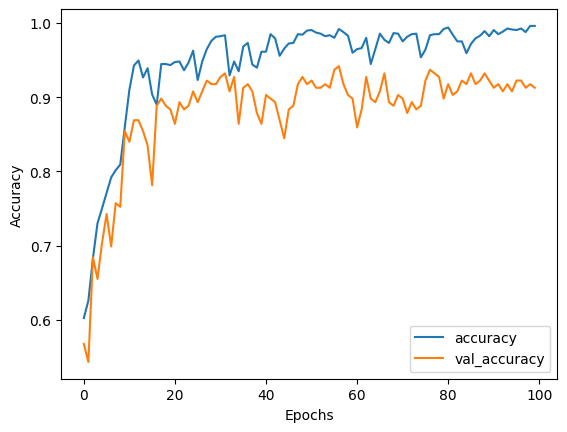

In [ ]:
pd.DataFrame(history.history)
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.ylabel('Accuracy')
plt.xlabel('Epochs')

Text(0.5, 0, 'Epochs')

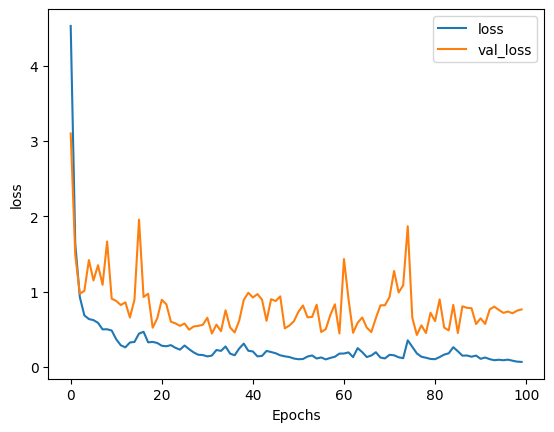

In [ ]:
pd.DataFrame(history.history)
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.ylabel('loss')
plt.xlabel('Epochs')